In [1]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm


import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF

import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [2]:
files = {
    0.0: "c2_from_c1_augmented_llama3_temp_0_0.csv",
    0.1: "c2_from_c1_augmented_llama3_temp_0_1.csv",
    0.2: "c2_from_c1_augmented_llama3_temp_0_2.csv",
    0.3: "c2_from_c1_augmented_llama3_temp_0_3.csv",
    0.4: "c2_from_c1_augmented_llama3_temp_0_4.csv",
    0.5: "c2_from_c1_augmented_llama3_temp_0_5.csv",
    0.6: "c2_from_c1_augmented_llama3_temp_0_6.csv",
    0.7: "c2_from_c1_augmented_llama3_temp_0_7.csv",
    0.8: "c2_from_c1_augmented_llama3_temp_0_8.csv",
    0.9: "c2_from_c1_augmented_llama3_temp_0_9.csv",
    1.0: "c2_from_c1_augmented_llama3_temp_1_0.csv",
    1.1: "c2_from_c1_augmented_llama3_temp_1_1.csv",
    1.2: "c2_from_c1_augmented_llama3_temp_1_2.csv",
    1.3: "c2_from_c1_augmented_llama3_temp_1_3.csv",
    1.4: "c2_from_c1_augmented_llama3_temp_1_4.csv",
    1.5: "c2_from_c1_augmented_llama3_temp_1_5.csv",
}

# Вспомогательные функции подсчета метрик

In [3]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [4]:
def bertscore_pair(original_text, augmented_text, model_type="DeepPavlov/rubert-base-cased"):
    P, R, F1 = score(
        [augmented_text],      
        [original_text],       
        model_type=model_type,
        num_layers=12,
        lang="ru",
        verbose=False
    )

    return {
        "precision": P.item(),
        "recall": R.item(),
        "f1": F1.item()
    }

In [5]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    return 1 - normalized_levenshtein_distance(original, augmented)

In [6]:
def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [7]:
def bleu_score(original, augmented):
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение исходных и аугментированных текстов внутри одной температуры

In [8]:
def calculate_pair_metrics(original, augmented):
    return {
        "bert_score": bertscore_pair(original, augmented),
        "jaccard_lemmas": jaccard_similarity_lemmas(original, augmented),
        "common_words_ratio": common_words_ratio(original, augmented),
        "levenshtein_distance": normalized_levenshtein_distance(original, augmented),
        "levenshtein_similarity": normalized_levenshtein_similarity(original, augmented),
        "rouge_l": rouge_l_f1(original, augmented),
        "bleu": bleu_score(original, augmented),
        "chrf": chrf_score(original, augmented),
    }

In [9]:
all_rows = []

for temp, path in files.items():
    df = pd.read_csv(path)
    

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"T={temp}. Обработка строк"):
        original = row['text']
        augmented = row['augmented-text']

        metrics = calculate_pair_metrics(original, augmented)

        metrics["temperature"] = temp
        metrics["original"] = original
        metrics["augmented"] = augmented

        all_rows.append(metrics)

pair_metrics_df = pd.DataFrame(all_rows)

T=0.0. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=0.1. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=0.2. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=0.3. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=0.4. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

...

T=1.1. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=1.2. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=1.3. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=1.4. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

T=1.5. Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

In [10]:
pair_metrics_df['bert_score_precision'] = [pair_metrics_df['bert_score'][i]['precision'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_recall'] = [pair_metrics_df['bert_score'][i]['recall'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_f1'] = [pair_metrics_df['bert_score'][i]['f1'] for i in range(len(pair_metrics_df))]

del pair_metrics_df['bert_score']

pair_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature,original,augmented,bert_score_precision,bert_score_recall,bert_score_f1
0,0.295455,0.866667,0.761468,0.238532,0.347826,0.097932,0.397360,0.0,И я понял: это моя жена. На бледном лице сияют...,"Я пришел к выводу, что это моя жена. На ее лиц...",0.473152,0.617010,0.535589
1,0.307692,0.500000,0.546584,0.453416,0.411765,0.142307,0.491640,0.0,"Получается безвыходная ситуация: человек, обла...","Ситуация, когда человек, располагающий свободн...",0.651213,0.633624,0.642298
2,0.478261,0.916667,0.671687,0.328313,0.453333,0.180248,0.673932,0.0,"Почитание святого Георгия, возникшее, вероятно...","Святого Георгия почитание, вероятно, возникшее...",0.595068,0.707735,0.646529
3,0.136364,0.285714,0.742537,0.257463,0.156863,0.078615,0.337783,0.0,У них всего-навсего разное представление о том...,"Взаимные представления о том, что является пра...",0.486147,0.513618,0.499505
4,0.229167,0.423077,0.635688,0.364312,0.285714,0.033785,0.350254,0.0,Большинство людей вокруг меня на протяжении вс...,"Большинство индивидуумов, окружающих меня в те...",0.581634,0.646917,0.612541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,0.195122,0.470588,0.754579,0.245421,0.122449,0.028229,0.352225,1.5,"Более того, опрос ВЦИОМа показал, что правосла...",Приводимые данные опроса ВЦИОМа указывают на с...,0.523784,0.645997,0.578507
1916,0.404762,0.680000,0.550820,0.449180,0.358209,0.103533,0.519498,1.5,В России традиционными героями новогодней ёлки...,В российской традиции герои новогодней ёлки пр...,0.619139,0.752770,0.679446
1917,0.186047,0.444444,0.687500,0.312500,0.307692,0.143616,0.382054,1.5,Любой квалифицированный сотрудник сейчас имеет...,Современный квалифицированный специалист облад...,0.576578,0.697745,0.631401
1918,0.242424,0.444444,0.690058,0.309942,0.272727,0.044573,0.354464,1.5,"Мне кажется, что вот это москвичам удавалось л...","Понимая, что успешность москвичей в выполнении...",0.516833,0.556695,0.536024


In [11]:
metric_columns = [
    "bert_score_precision",
    "bert_score_recall",
    "bert_score_f1",
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

results_df = (
    pair_metrics_df
    .groupby("temperature")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [12]:
results_df_flat = results_df.copy()

results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in results_df_flat.columns
]

results_df_flat = results_df_flat.reset_index()

In [13]:
results_df['bert_score_precision']

,mean,std,min,max
temperature,,,,
0.0,0.569078,0.089975,0.397456,0.860854
0.1,0.571314,0.095037,0.256114,0.853209
0.2,0.573844,0.088253,0.384878,0.809376
0.3,0.567159,0.092632,0.383012,0.802173
0.4,0.572724,0.091396,0.400090,0.855929
0.5,0.559511,0.094103,0.240505,0.795770
0.6,0.559183,0.095205,0.238550,0.798668
0.7,0.566335,0.103621,0.273505,0.811519
0.8,0.543853,0.103497,0.259833,0.846837


In [14]:
results_df['bert_score_recall']

,mean,std,min,max
temperature,,,,
0.0,0.645961,0.101713,0.329203,0.916448
0.1,0.650288,0.103413,0.320237,0.891770
0.2,0.649630,0.092091,0.440598,0.873817
0.3,0.645282,0.102771,0.410344,0.851102
0.4,0.653736,0.098593,0.412529,0.890756
0.5,0.633296,0.105327,0.297210,0.929434
0.6,0.640851,0.093817,0.315077,0.880673
0.7,0.644583,0.109731,0.373664,0.893299
0.8,0.622416,0.108973,0.329243,0.888368


In [15]:
results_df['bert_score_f1']

,mean,std,min,max
temperature,,,,
0.0,0.603799,0.091271,0.364989,0.856801
0.1,0.607018,0.095163,0.284608,0.849970
0.2,0.608117,0.085941,0.440220,0.812160
0.3,0.602651,0.094161,0.396208,0.814644
0.4,0.609365,0.090828,0.406214,0.851504
0.5,0.592922,0.095868,0.265868,0.857424
0.6,0.595812,0.090614,0.271525,0.820091
0.7,0.601498,0.102327,0.336797,0.811472
0.8,0.579365,0.102811,0.290449,0.838259


In [16]:
results_df['jaccard_lemmas']

,mean,std,min,max
temperature,,,,
0.0,0.313723,0.110678,0.096154,0.714286
0.1,0.317745,0.108916,0.019608,0.629630
0.2,0.325819,0.098005,0.140000,0.600000
0.3,0.317594,0.106857,0.083333,0.548387
0.4,0.323406,0.111679,0.113208,0.677419
0.5,0.300884,0.111649,0.000000,0.714286
0.6,0.313579,0.110964,0.000000,0.600000
0.7,0.312675,0.111302,0.073529,0.636364
0.8,0.296057,0.122999,0.014493,0.687500


In [17]:
results_df['common_words_ratio']

,mean,std,min,max
temperature,,,,
0.0,0.620357,0.163581,0.238095,1.000000
0.1,0.621101,0.162774,0.050000,1.000000
0.2,0.627023,0.144791,0.304348,0.954545
0.3,0.620763,0.151826,0.266667,0.958333
0.4,0.627700,0.152999,0.333333,0.954545
0.5,0.592364,0.177289,0.000000,1.000000
0.6,0.608673,0.162619,0.000000,1.000000
0.7,0.607244,0.156420,0.266667,1.000000
0.8,0.584280,0.172078,0.052632,0.916667


In [18]:
results_df['levenshtein_distance']

,mean,std,min,max
temperature,,,,
0.0,0.643835,0.104827,0.315126,0.810241
0.1,0.632384,0.108276,0.337449,0.850515
0.2,0.629934,0.104346,0.286232,0.821429
0.3,0.633633,0.107177,0.314721,0.838542
0.4,0.627656,0.107107,0.337349,0.785479
0.5,0.647855,0.098368,0.368182,0.878788
0.6,0.633762,0.108273,0.354067,0.913333
0.7,0.634519,0.108950,0.370370,0.880000
0.8,0.650804,0.109693,0.290323,0.919786


In [19]:
results_df['levenshtein_similarity']

,mean,std,min,max
temperature,,,,
0.0,0.356165,0.104827,0.189759,0.684874
0.1,0.367616,0.108276,0.149485,0.662551
0.2,0.370066,0.104346,0.178571,0.713768
0.3,0.366367,0.107177,0.161458,0.685279
0.4,0.372344,0.107107,0.214521,0.662651
0.5,0.352145,0.098368,0.121212,0.631818
0.6,0.366238,0.108273,0.086667,0.645933
0.7,0.365481,0.108950,0.120000,0.629630
0.8,0.349196,0.109693,0.080214,0.709677


In [20]:
results_df['rouge_l']

,mean,std,min,max
temperature,,,,
0.0,0.334532,0.132902,0.088235,0.724638
0.1,0.338223,0.132650,0.037736,0.722222
0.2,0.340636,0.128220,0.083333,0.701754
0.3,0.328906,0.127297,0.080000,0.620690
0.4,0.340074,0.141981,0.043478,0.714286
0.5,0.308451,0.132681,0.000000,0.753623
0.6,0.335775,0.139513,0.000000,0.622951
0.7,0.327029,0.130207,0.064516,0.631579
0.8,0.301975,0.143569,0.023810,0.789474


In [21]:
results_df['bleu']

,mean,std,min,max
temperature,,,,
0.0,0.127145,0.097754,0.012110,0.498037
0.1,0.127310,0.099177,0.014934,0.487321
0.2,0.130805,0.097052,0.010841,0.488401
0.3,0.120475,0.090029,0.011978,0.446771
0.4,0.126755,0.105703,0.011373,0.516603
0.5,0.107760,0.080815,0.011621,0.495792
0.6,0.125356,0.098181,0.009884,0.431725
0.7,0.120909,0.098310,0.010683,0.532973
0.8,0.102492,0.097321,0.008079,0.512335


In [22]:
results_df['chrf']

,mean,std,min,max
temperature,,,,
0.0,0.488883,0.114698,0.298653,0.822476
0.1,0.489929,0.115256,0.077968,0.785530
0.2,0.490714,0.107429,0.275318,0.785003
0.3,0.484932,0.110147,0.292107,0.726201
0.4,0.488210,0.114342,0.261940,0.816694
0.5,0.463355,0.112694,0.019676,0.841404
0.6,0.481186,0.113050,0.014468,0.764320
0.7,0.472837,0.105726,0.240416,0.735413
0.8,0.449760,0.120308,0.005877,0.804222


In [23]:
def plot_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["temperature"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
    plt.xlabel("Температура генерации")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

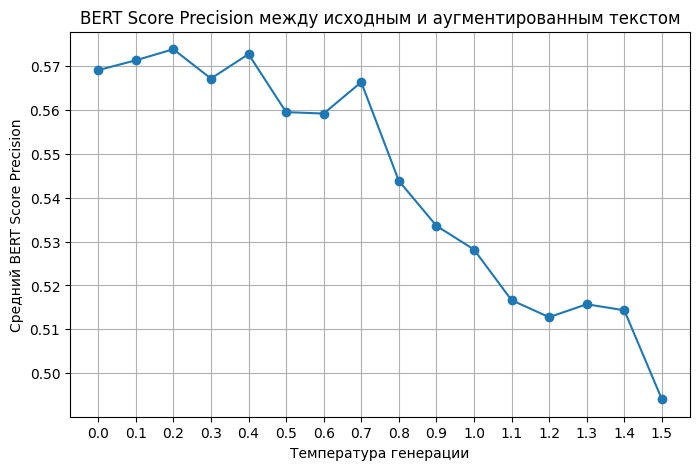

In [24]:
plot_metric(
    results_df_flat,
    "bert_score_precision",
    "BERT Score Precision между исходным и аугментированным текстом",
    "Средний BERT Score Precision"
)

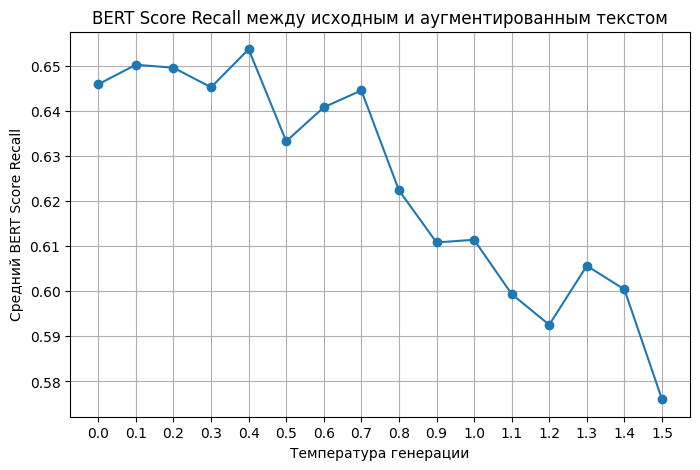

In [25]:
plot_metric(
    results_df_flat,
    "bert_score_recall",
    "BERT Score Recall между исходным и аугментированным текстом",
    "Средний BERT Score Recall"
)

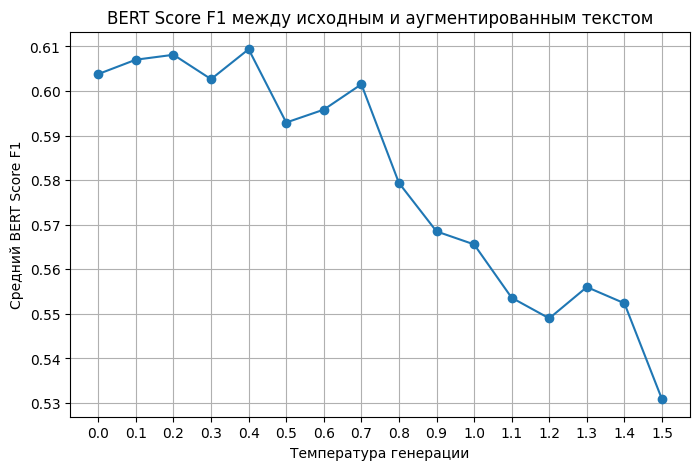

In [26]:
plot_metric(
    results_df_flat,
    "bert_score_f1",
    "BERT Score F1 между исходным и аугментированным текстом",
    "Средний BERT Score F1"
)

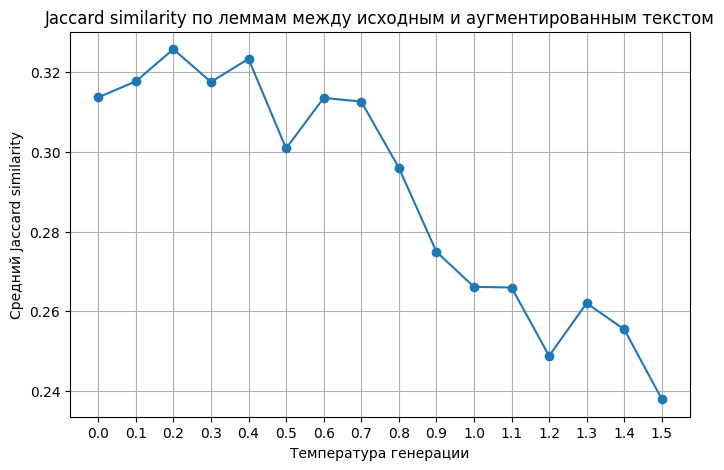

In [27]:
plot_metric(
    results_df_flat,
    "jaccard_lemmas",
    "Jaccard similarity по леммам между исходным и аугментированным текстом",
    "Средний Jaccard similarity"
)

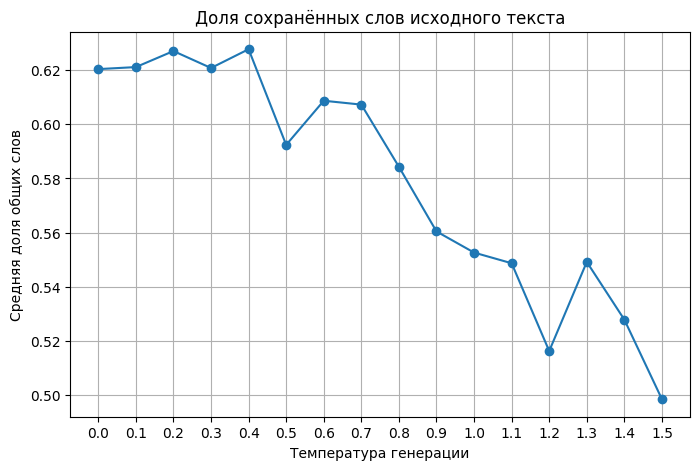

In [28]:
plot_metric(
    results_df_flat,
    "common_words_ratio",
    "Доля сохранённых слов исходного текста",
    "Средняя доля общих слов"
)


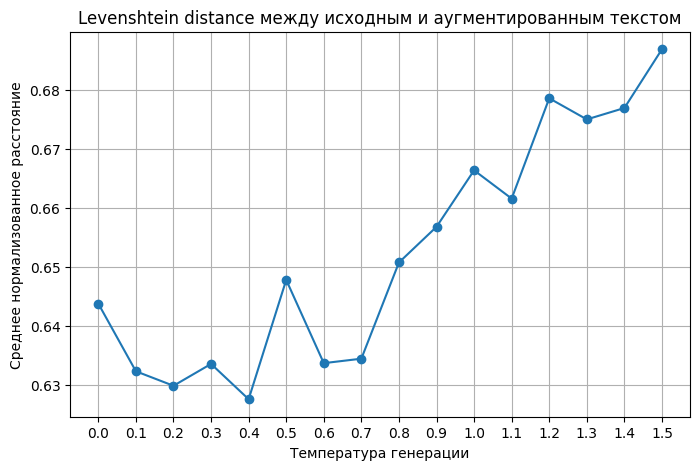

In [29]:
plot_metric(
    results_df_flat,
    "levenshtein_distance",
    "Levenshtein distance между исходным и аугментированным текстом",
    "Среднее нормализованное расстояние"
)

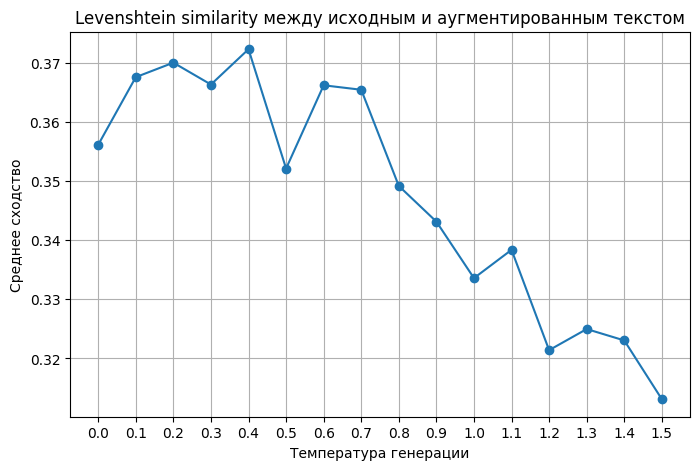

In [30]:
plot_metric(
    results_df_flat,
    "levenshtein_similarity",
    "Levenshtein similarity между исходным и аугментированным текстом",
    "Среднее сходство"
)

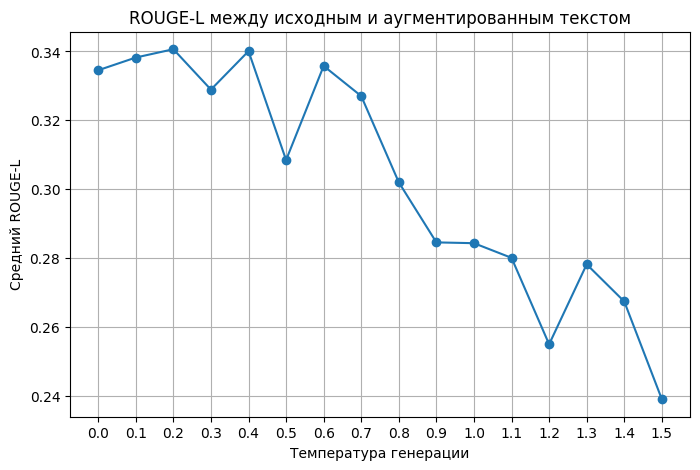

In [31]:
plot_metric(
    results_df_flat,
    "rouge_l",
    "ROUGE-L между исходным и аугментированным текстом",
    "Средний ROUGE-L"
)

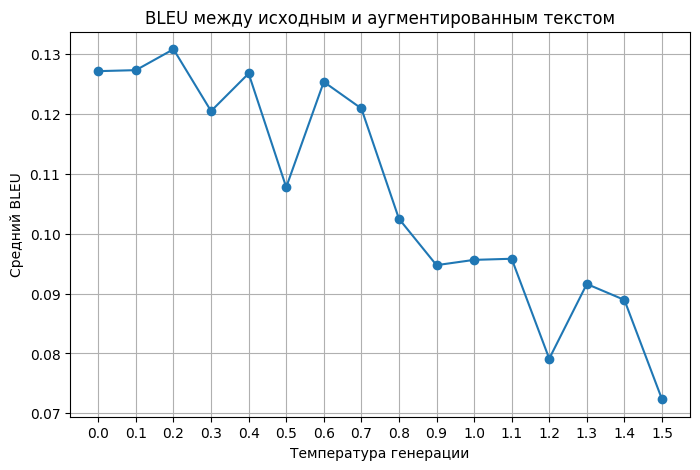

In [32]:
plot_metric(
    results_df_flat,
    "bleu",
    "BLEU между исходным и аугментированным текстом",
    "Средний BLEU"
)

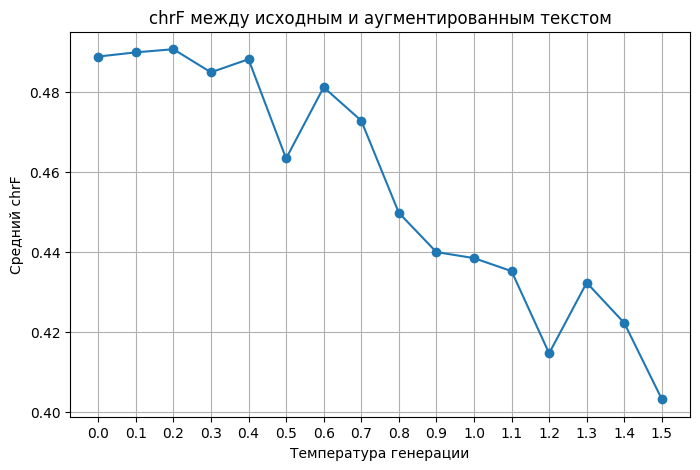

In [33]:
plot_metric(
    results_df_flat,
    "chrf",
    "chrF между исходным и аугментированным текстом",
    "Средний chrF"
)